<div style="text-align: justify; max-width: 90ch">

# Lecture 02 exercises (solutions)

Exercises are tagged with the goal they practise (see `reading_material/goals_02.md`); `[O]` marks stretch exercises. Time bands:

- 15 min (quick)
- 45 min (realistic)
- 90 min (stretch)

Before you start:

- Run the configuration cell first.
- Ollama must be running with the models pulled.
- The MLflow server must be started (guide `02a_mlflow_server`).
- `lec_02d` must have run once: several exercises reuse its Chroma index.

</div>

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import ollama
import pandas as pd
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_ollama import ChatOllama, OllamaEmbeddings
from mlflow.entities import SpanType

from llm_course.checks import check_mlflow
from llm_course.corpus import (
    fetch_wikipedia_pages,
    load_corpus,
    load_eval_set,
    load_sections,
)
from llm_course.rag import (
    LECTURE_KINDS,
    hit_rate_and_mrr,
    make_rag_chain,
    source_rank,
    split_documents,
)

In [2]:
# --- Course configuration: edit TIER only; settings in .env (Read: 01d_env_hugging_face) ---
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

REPO = Path.cwd().resolve().parents[1]  # this notebook runs from reading_material/
load_dotenv(REPO / ".env")  # load your .env settings: OLLAMA_HOST, HF_TOKEN, ...
TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
os.environ.setdefault(
    "HF_HUB_DISABLE_PROGRESS_BARS", "1"
)  # no download bars in saved outputs
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
# To override .env in this notebook only, uncomment and edit (never a token):
# OLLAMA_HOST = "http://192.168.1.20:11434"
# MLFLOW_URI = "http://127.0.0.1:5011"
EXPERIMENT = "llm-course-02-exercises"
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

### Exercise 2.1 [G1, G2] Your own similarity heatmap (15 min)

Write ten short sentences of your own:

- three topics
- one pair that means the same thing in different words
- one sentence in Greek (or with its word order reversed)

Embed them, plot the cosine-similarity heatmap as in `lec_02a` section 3, and in a Markdown cell name the most surprising pair and explain it.

</div>

Ollama OK at http://localhost:11434; models ready: nomic-embed-text


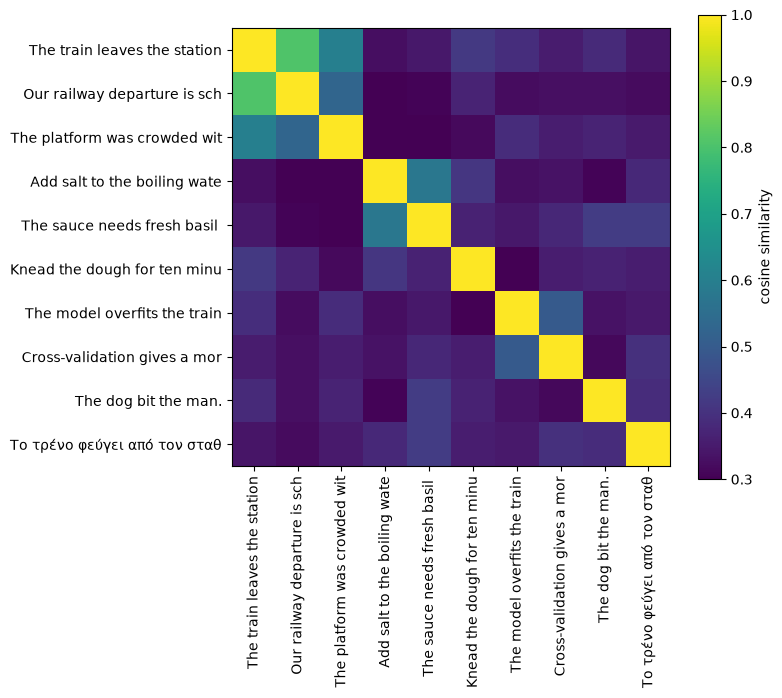

In [3]:
check_ollama(OLLAMA_HOST, [EMBED_MODEL])
client = ollama.Client(host=OLLAMA_HOST)

sentences = [
    "The train leaves the station at nine.",
    "Our railway departure is scheduled for 9 a.m.",
    "The platform was crowded with commuters.",
    "Add salt to the boiling water before the pasta.",
    "The sauce needs fresh basil and garlic.",
    "Knead the dough for ten minutes.",
    "The model overfits the training data.",
    "Cross-validation gives a more reliable score.",
    "The dog bit the man.",
    "Το τρένο φεύγει από τον σταθμό στις εννέα.",
]

vectors = np.array(client.embed(model=EMBED_MODEL, input=sentences).embeddings)
unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
similarity = unit @ unit.T

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(similarity, cmap="viridis", vmin=0.3, vmax=1)
labels = [s[:28] for s in sentences]
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
fig.colorbar(image, label="cosine similarity")
plt.tight_layout()
plt.show()

In [4]:
pairs = [
    (similarity[i, j], sentences[i], sentences[j])
    for i in range(10)
    for j in range(i + 1, 10)
]

for score, a, b in sorted(pairs, reverse=True)[:3]:
    print(f"{score:.3f} | {a} | {b}")

print(f"English vs Greek train sentence: {similarity[0, 9]:.3f}")

0.806 | The train leaves the station at nine. | Our railway departure is scheduled for 9 a.m.
0.601 | The train leaves the station at nine. | The platform was crowded with commuters.
0.578 | Add salt to the boiling water before the pasta. | The sauce needs fresh basil and garlic.
English vs Greek train sentence: 0.339


<div style="text-align: justify; max-width: 90ch">

**Example answer.** The paraphrase pair scores highest (about 0.8 in example runs) although the two sentences share no word,
and in example runs the three topics formed clear blocks. The surprise is the Greek sentence: it is a translation of the first sentence,
yet in example runs it scored below 0.4 against it (the printed `English vs Greek` line), lower than the English sentence about the platform,
which only shares the topic of trains. For this embedding model, a translation can sit further from its original than a sentence that merely shares the topic.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.2 [G3, G4] Find the failing step from code (15 min)

Rebuild the traced pipeline of `lec_02b`: the sections come from `load_sections`, the vectors from the cache `lec_02b` saved in `data/`.
Ask "What is the difference between Ridge and Lasso?", then, from code only, print the sources and scores in the retriever span and the length of the prompt the model received.
Did retrieval or the model decide the quality of this answer?

</div>

In [5]:
sections = load_sections(REPO / "corpus" / "uoa_py_course", lectures=[10, 11, 12, 13])

vectors_path = DATA_DIR / "lec_02b_section_vectors.npy"

if vectors_path.exists() and len(np.load(vectors_path)) == len(sections):
    vectors = np.load(vectors_path)
else:  # lec_02b has not run yet: embed the sections here (slow on a CPU)
    vectors = np.array(
        [
            v
            for start in range(0, len(sections), 32)
            for v in client.embed(
                model=EMBED_MODEL,
                input=[s["text"][:4000] for s in sections[start : start + 32]],
            ).embeddings
        ]
    )

vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

PROMPT = """Answer the question using only the course notes below.
If the notes do not contain the answer, say so. Name the source file you used.

Notes:
{notes}

Question: {question}"""


@mlflow.trace(span_type=SpanType.RETRIEVER)
def retrieve(question, k=3):
    question_vector = np.array(
        client.embed(model=EMBED_MODEL, input=question).embeddings[0]
    )
    scores = vectors @ (question_vector / np.linalg.norm(question_vector))
    best = np.argsort(-scores)[:k]
    return [{**sections[i], "score": round(float(scores[i]), 3)} for i in best]


@mlflow.trace(span_type=SpanType.CHAT_MODEL)
def generate(prompt):
    response = client.chat(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        think=False,
        options={"temperature": 0, "num_predict": 200, "num_ctx": 8192},
    )
    return response.message.content.strip()


@mlflow.trace(span_type=SpanType.CHAIN)
def answer(question, k=3):
    found = retrieve(question, k)
    notes = "\n\n".join(f"[source: {s['source']}]\n{s['text'][:4000]}" for s in found)
    return generate(PROMPT.format(notes=notes, question=question))

In [6]:
check_mlflow(MLFLOW_URI)
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)
mlflow.tracing.disable_notebook_display()

print(answer("What is the difference between Ridge and Lasso?"))

MLflow OK at http://127.0.0.1:5010


The difference between Ridge and Lasso lies in the type of norm they use to penalize the coefficient vector. 

- **Ridge** uses the **L2 norm**, which is the square root of the sum of the squares of the coefficients. This penalty shrinks all coefficients towards zero but does not set any of them exactly to zero. Ridge regression is known for its ability to handle multicollinearity by shrinking coefficients smoothly.

- **Lasso** uses the **L1 norm**, which is the sum of the absolute values of the coefficients. This penalty can set some coefficients exactly to zero, leading to automatic feature selection. Lasso is effective for feature selection and can handle high-dimensional data well.

The source file used is: `lec_11e_polynomial_regression.md`.


In [7]:
trace = mlflow.get_trace(mlflow.get_last_active_trace_id(), flush=True)

retriever_span = next(s for s in trace.data.spans if s.span_type == SpanType.RETRIEVER)
model_span = next(s for s in trace.data.spans if s.span_type == SpanType.CHAT_MODEL)

print(pd.DataFrame(retriever_span.outputs)[["score", "source", "heading"]])
print("prompt characters:", len(model_span.inputs["prompt"]))

   score                                             source  \
0  0.642        lecture_11/lec_11e_polynomial_regression.md   
1  0.621        lecture_11/lec_11e_polynomial_regression.md   
2  0.609  lecture_11/lec_11d_advanced_linear_model_coeff...   

                                             heading  
0  ## What this notebook deliberately leaves for ...  
1          ## Primer — what are the L1 and L2 norms?  
2                                     ## What's next  
prompt characters: 5368


<div style="text-align: justify; max-width: 90ch">

**Example answer.** Retrieval decides, and the retriever span shows how. If it holds a section of `lec_11e`, the notebook with the L1/L2 primer and Ridge and Lasso,
the model can answer from it and name it. If it holds only near-empty headings or unrelated sections instead, a good model says that the notes do not contain the answer.
Check which case your span shows, and whether the file the answer names is among its sources. The prompt length tells you how much text the model received;
it says nothing about whether that text answers.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.3 [G5, G8] Chunk size against hit rate (45 min)

For chunk sizes 400, 800 and 1600 characters (overlap one eighth of the size), index lectures 10 to 13 in a temporary in-memory Chroma collection and measure hit@4 and MRR,
with the lecture filter, on the evaluation-set questions whose expected source is in those lectures. Put the three rows in a table and write three sentences:
which size would you choose, and what would change your mind?

</div>

In [8]:
embeddings = OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_HOST)

docs_10_13 = load_corpus(REPO / "corpus" / "uoa_py_course", lectures=[10, 11, 12, 13])

LECTURES = ("lecture_10", "lecture_11", "lecture_12", "lecture_13")
eval_10_13 = [
    q
    for q in load_eval_set(REPO / "corpus" / "eval" / "qa_eval_set.jsonl")
    if q["expected_source"].startswith(LECTURES)
]

LECTURE_NOTES = {"kind": {"$in": LECTURE_KINDS}}

rows = []

for size in [400, 800, 1600]:
    chunks = split_documents(docs_10_13, chunk_size=size, chunk_overlap=size // 8)

    store = Chroma(
        collection_name=f"sweep_{size}",
        embedding_function=embeddings,
        collection_metadata={"hnsw:space": "cosine"},
    )

    started = time.time()

    for start in range(0, len(chunks), 256):
        store.add_documents(chunks[start : start + 256])

    seconds = time.time() - started

    ranks = [
        source_rank(
            store.similarity_search(q["question"], k=8, filter=LECTURE_NOTES),
            q["expected_source"],
        )
        for q in eval_10_13
    ]
    scores = hit_rate_and_mrr(ranks, ks=(4,))

    rows.append(
        {
            "chunk_size": size,
            "chunks": len(chunks),
            "embed s": round(seconds, 1),
            **scores,
        }
    )
    store.delete_collection()

print(len(eval_10_13), "questions")

pd.DataFrame(rows).round(2)

13 questions


,chunk_size,chunks,embed s,hit@4,MRR
0,400,2623,14.5,1.0,0.88
1,800,1371,10.1,1.0,0.95
2,1600,701,8.0,1.0,0.96


<div style="text-align: justify; max-width: 90ch">

**Example answer.** In example runs hit@4 was equal or nearly equal across the three sizes, and MRR rose with the chunk size;
400 characters also produced about twice the chunks of 800. In those runs larger chunks ranked the right file slightly higher:
each carries more context. I would still keep 800 for now: compare the MRR column, where the gain from 800 to 1600 was small in those runs,
and four 1600-character chunks double the notes in every prompt. A larger evaluation set that confirmed the gap would make me switch.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.4 [G7] Add a file without re-embedding everything (45 min)

Create a persistent collection `my_notes` in `data/chroma_exercise/` holding lecture 13 plus a short Markdown note of your own.
Show that running the ingestion twice keeps the count, then add a second note and show that the count grows only by that note's chunks.
Finally, ask a question that only your notes answer. Hint: `store.get(ids=[...])` tells you which ids are already stored.

</div>

In [9]:
embeddings = OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_HOST)

store = Chroma(
    collection_name="my_notes",
    embedding_function=embeddings,
    persist_directory=str(DATA_DIR / "chroma_exercise"),
    collection_metadata={"hnsw:space": "cosine"},
)
store.reset_collection()  # start empty, so this cell gives the same output on every run


def ingest(chunks):
    """Add only the chunks whose ids are not stored yet; return how many were added."""
    ids = [f"{c.metadata['source']}#{c.metadata['start_index']}" for c in chunks]
    stored = set(store.get(ids=ids, include=[])["ids"])
    new = [(chunk, i) for chunk, i in zip(chunks, ids) if i not in stored]
    if new:
        store.add_documents([chunk for chunk, _ in new], ids=[i for _, i in new])
    return len(new)


def note(name, text):
    """Save a Markdown note in data/my_notes/ and return it as one Document."""
    path = DATA_DIR / "my_notes" / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return Document(
        page_content=text,
        metadata={
            "source": f"my_notes/{name}",
            "lecture": 0,
            "kind": "lecture",
            "title": name,
        },
    )


lecture_13 = split_documents(
    load_corpus(REPO / "corpus" / "uoa_py_course", lectures=[13])
)

note_1 = note(
    "study_group.md",
    "# Study group\n\nOur study group meets on Thursdays at 18:00 in room B12. "
    "Bring the lecture 13 notebooks and one question each.\n",
)

print("first ingest: ", ingest(lecture_13 + split_documents([note_1])), "chunks added")
print("second ingest:", ingest(lecture_13 + split_documents([note_1])), "chunks added")
print("stored:", len(store.get(include=[])["ids"]))

first ingest:  322 chunks added
second ingest: 0 chunks added
stored: 322


In [10]:
note_2 = note(
    "exam.md",
    "# Exam\n\nThe written exam is on 18 January and lasts two hours. "
    "Notes are not allowed, but a one-page formula sheet is.\n",
)

print("new note:", ingest(split_documents([note_2])), "chunks added")
print("stored:", len(store.get(include=[])["ids"]))

new note: 1 chunks added
stored: 323


In [11]:
for question in ["When does my study group meet?", "How long is the exam?"]:
    best = store.similarity_search(question, k=1)[0]
    print(
        f"{question} -> {best.metadata['source']}: {best.page_content.splitlines()[-1]}"
    )

When does my study group meet? -> my_notes/study_group.md: Our study group meets on Thursdays at 18:00 in room B12. Bring the lecture 13 notebooks and one question each.
How long is the exam? -> my_notes/exam.md: The written exam is on 18 January and lasts two hours. Notes are not allowed, but a one-page formula sheet is.


<div style="text-align: justify; max-width: 90ch">

**Example answer.** The first ingestion added every chunk of lecture 13 plus the note, the second added none because every id was already stored,
and the second note added exactly its own chunk. The ids combine the file name and the chunk's start position, so they stay the same as long as the file does not change.
Check that the top result for each question is your own note: retrieval can only find the study group because a document says so,
and a RAG chain can only answer from it, which is the point of RAG.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.5 [G6] A question that needs a filter (45 min)

Find a question whose top four results in the `course_notes` collection change completely when you restrict the search to one lecture,
with a metadata filter such as `{"lecture": 12}`. Show both tables, and explain in two sentences what the filter fixed and what it cannot fix.

</div>

In [12]:
notes_store = Chroma(
    collection_name="course_notes",
    embedding_function=OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_HOST),
    persist_directory=str(DATA_DIR / "chroma"),
    collection_metadata={"hnsw:space": "cosine"},
)

assert len(notes_store.get(include=[])["ids"]) > 0, (
    "Run lec_02d once: it builds this collection."
)


def top4(question, search_filter=None):
    results = notes_store.similarity_search_with_score(
        question, k=4, filter=search_filter
    )
    return pd.DataFrame(
        [
            {
                "distance": round(d, 3),
                "source": doc.metadata["source"],
                "heading": doc.metadata["heading"][:45],
            }
            for doc, d in results
        ]
    )


question = "What are the assumptions of the model?"

print(top4(question))

   distance                                             source  \
0     0.299                             lecture_11/goals_11.md   
1     0.312  lecture_11/lec_11b_linear_regression_assumptio...   
2     0.324  lecture_11/lec_11b_linear_regression_assumptio...   
3     0.336   lecture_11/lec_11c_multiple_linear_regression.md   

                                         heading  
0                  Notebooks (mandatory reading)  
1                 The four classical assumptions  
2  Lecture 11b — The four assumptions of linear   
3                      What this notebook covers  


In [13]:
print(top4(question, {"lecture": 12}))

   distance                                             source  \
0     0.348                  lecture_12/lec_12e_naive_bayes.md   
1     0.350                             lecture_12/goals_12.md   
2     0.366  lecture_12/lec_12b_logit_probit_values_predict...   
3     0.371  lecture_12/lec_12c_logistic_regression_assumpt...   

                                         heading  
0      What the fitted estimator actually stores  
1                        Optional / Career-track  
2  Vocabulary: coefficient values, log-odds, pro  
3  Lecture 12c — Logistic Regression: Assumption  


<div style="text-align: justify; max-width: 90ch">

**Example answer.** Without a filter, "the model" is ambiguous, and in example runs the results came mostly from lecture 11's "four assumptions" of linear regression.
Restricted to lecture 12, every result comes from lecture 12: read their headings to see how many actually discuss an assumption.
The filter fixes ambiguity when you know where to look (a student working on lecture 12); it cannot fix a vague question:
nothing in the question names logistic regression, so `lec_12c`, the notebook on its assumptions, gets no help from the wording and may rank low or not at all.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.6 [G6, G7] The chain on a hard question (15 min)

Build the RAG chain of `lec_02d` twice, with and without a content filter for the class name, and run both on "What does GridSearchCV do?" with MLflow autolog on.
From each trace, print the sources in the retriever span and the token usage. Which answer would you trust, and did the filter change the prompt the model received?
How can you tell from the trace?

</div>

In [14]:
llm = ChatOllama(
    model=CHAT_MODEL,
    base_url=OLLAMA_HOST,
    reasoning=False,
    temperature=0,
    num_predict=200,
    num_ctx=8192,
)

mlflow.langchain.autolog()

question = "What does GridSearchCV do?"

for label, extra in [
    ("lecture filter only", {}),
    ("with the content filter", {"where_document": {"$contains": "GridSearchCV"}}),
]:
    retriever = notes_store.as_retriever(
        search_kwargs={"k": 4, "filter": LECTURE_NOTES, **extra}
    )
    answer_text = make_rag_chain(retriever, llm).invoke(question)

    trace = mlflow.get_trace(mlflow.get_last_active_trace_id(), flush=True)
    retriever_span = next(
        s for s in trace.data.spans if s.span_type == SpanType.RETRIEVER
    )

    print(f"--- {label}: {trace.info.token_usage}")
    print("sources:", [doc["metadata"]["source"] for doc in retriever_span.outputs])
    print(answer_text[:400])

--- lecture filter only: {'input_tokens': 661, 'output_tokens': 200, 'total_tokens': 861}
sources: ['lecture_13/lec_13a_gridsearchcv_hyperparameter_tuning.md', 'lecture_12/lec_12d_logistic_regression_hyperparameters.md', 'lecture_13/lec_13b_pipelines_preprocessing_models.md', 'lecture_13/lec_13a_gridsearchcv_hyperparameter_tuning.md']
GridSearchCV is a method used in machine learning to perform **hyperparameter tuning**. It systematically searches through a predefined grid of hyperparameters (or a random sample from a distribution) to find the hyperparameters that yield the best performance on a validation set.

It works by:
- Using **k-fold cross-validation** to evaluate each combination of hyperparameters.
- For every combina


--- with the content filter: {'input_tokens': 661, 'output_tokens': 200, 'total_tokens': 861}
sources: ['lecture_13/lec_13a_gridsearchcv_hyperparameter_tuning.md', 'lecture_12/lec_12d_logistic_regression_hyperparameters.md', 'lecture_13/lec_13b_pipelines_preprocessing_models.md', 'lecture_13/lec_13a_gridsearchcv_hyperparameter_tuning.md']
GridSearchCV is a method used in machine learning to perform **hyperparameter tuning**. It systematically searches through a predefined grid of hyperparameters (or a random sample from a distribution) to find the hyperparameters that yield the best performance on a validation set.

### Key Features of GridSearchCV:
- It uses **k-fold cross-validation** to evaluate each combination of hyperparamete


<div style="text-align: justify; max-width: 90ch">

**Example answer.** Compare the sources in the two retriever spans. If they differ, the content filter replaced chunks that only resemble the question with chunks that contain `GridSearchCV`,
and only the second answer rests on the notes. If they are identical, the embedding already ranked the right chunks first and the filter changed nothing on this run.
Either way, trust the answer whose retrieved chunks contain what it says: the model knows `GridSearchCV` from its training,
so a fluent answer can come from memory with no source behind it, which is exactly what lecture 3 learns to detect. The token usage shows how much text each prompt carried.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.7 [G8] Five questions of your own (45 min)

Write five questions about lectures 7 to 9, each with the file that answers it (`expected_source`, as in `corpus/eval/qa_eval_set.jsonl`).
Measure hit@4 and MRR with the lecture filter. For every miss, print the retrieved sources and decide: did the retriever fail, or was your expected source too narrow?

</div>

In [15]:
my_questions = [
    (
        "How do I make an interactive scatter plot with Plotly Express?",
        "lecture_08/lec_08a_interactive_plots.md",
    ),
    (
        "Which tools generate an automatic EDA report from a DataFrame?",
        "lecture_08/lec_08f_auto_EDA.md",
    ),
    (
        "Which Python frameworks turn a data analysis into a web app?",
        "lecture_08/lec_08g_web_app_frameworks.md",
    ),
    (
        "How does KMeans choose its initial centroids?",
        "lecture_09/lec_09b_kmeans_assumptions_caveats.md",
    ),
    (
        "When would I use Polars instead of pandas?",
        "lecture_07/lec_07c_updated_informed_data_management_modules.md",
    ),
]

LECTURE_NOTES = {"kind": {"$in": LECTURE_KINDS}}

ranks = []

for question, expected in my_questions:
    docs = notes_store.similarity_search(question, k=8, filter=LECTURE_NOTES)
    rank = source_rank(docs, expected)
    ranks.append(rank)

    if rank is None or rank > 4:
        print(f"MISS ({rank}): {question}")
        for doc in docs[:4]:
            print("    ", doc.metadata["source"], "|", doc.metadata["heading"][:50])

hit_rate_and_mrr(ranks, ks=(4,))

MISS (None): How does KMeans choose its initial centroids?
     lecture_09/lec_09d_kmeans_other_parameters.md | 2. `init` — how the first centroids are chosen
     lecture_09/lec_09e_kmeans_step_by_step_animations.md | 9. Visualising the KMeans algorithm step by step
     lecture_09/lec_09e_kmeans_step_by_step_animations.md | 9.1. Convergence of centroids at a fixed `K`
     lecture_09/lec_09a_kmeans_clustering.md | What is KMeans


{'hit@4': 0.8, 'MRR': 0.6666666666666667}

<div style="text-align: justify; max-width: 90ch">

**Example answer.** In one example run four of the five questions found their file in the top four (hit@4 = 0.8) and the KMeans question missed;
an MRR below the hit rate means some hits were not at rank 1. For each MISS, read the printed sources: in that run the first was `lec_09d`'s section "2.
`init` — how the first centroids are chosen", which answers the question better than the file I expected. That miss is not a retriever failure:
the expected source was too narrow. An evaluation set is data, and it needs the same review as any other data.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.8 [O1] Chroma against pgvector, measured (90 min, stretch)

Following `lec_02e`, load the course notes into PostgreSQL + pgvector and run the evaluation set of `lec_02d` against both stores,
with the lecture filter. Are hit@4 and MRR the same? Explain why, or why not.

</div>

In [16]:
# Optional group: needs `uv sync --group pgvector` and the database of guide 02b_docker_pgvector.
import psycopg
from langchain_postgres import PGVector

PG_URL = "{user}:{password}@localhost:{port}/{db}".format(
    user=os.environ.get("PG_USER", "course"),
    password=os.environ.get("PG_PASSWORD", "course"),
    port=os.environ.get("PG_PORT", "5433"),
    db=os.environ.get("PG_DB", "course"),
)

try:
    psycopg.connect("postgresql://" + PG_URL, connect_timeout=5).close()
    pg_ready = True
except psycopg.OperationalError:
    pg_ready = False
    print(
        "No PostgreSQL running: start it with `docker compose up -d` (guide 02b_docker_pgvector)."
    )

if pg_ready:
    pg_store = PGVector(
        embeddings=OllamaEmbeddings(model=EMBED_MODEL, base_url=OLLAMA_HOST),
        collection_name="course_notes",
        connection="postgresql+psycopg://" + PG_URL,
        use_jsonb=True,
    )

    if not pg_store.similarity_search(
        "test", k=1
    ):  # empty: run lec_02e section 2 first
        print("The pgvector collection is empty: run lec_02e once.")
    else:
        eval_set = load_eval_set(REPO / "corpus" / "eval" / "qa_eval_set.jsonl")

        rows = []

        for name, store in [("Chroma", notes_store), ("pgvector", pg_store)]:
            ranks = [
                source_rank(
                    store.similarity_search(q["question"], k=8, filter=LECTURE_NOTES),
                    q["expected_source"],
                )
                for q in eval_set
            ]
            rows.append({"store": name, **hit_rate_and_mrr(ranks, ks=(4,))})

        print(pd.DataFrame(rows).round(3))

      store  hit@4    MRR
0    Chroma    1.0  0.965
1  pgvector    1.0  0.965


<div style="text-align: justify; max-width: 90ch">

**Example answer.** In example runs the two rows were identical (if PostgreSQL is not running, the cell prints no table).
Both stores hold the same chunks, embedded by the same model, and both rank by cosine distance, so they usually return the same neighbours.
A small difference can still appear: Chroma's HNSW index is approximate, while pgvector without an index compares every vector exactly,
and a collection embedded with another version of the model holds other vectors. Retrieval quality comes from the chunks and the embedding model;
the store decides where the data lives and how it is operated, not what is found.

</div>

<div style="text-align: justify; max-width: 90ch">

### Exercise 2.9 [O2] A thousand chunks from Wikipedia (90 min, stretch)

Following `lec_02f`, fetch at least ten more Wikipedia pages on topics of the Python course (or pages of the Greek Wikipedia,
`lang="el"`, to test the Greek blind spot of `lec_02a`). Chunk them into more than 1,000 chunks and report:

- pages
- chunks
- embedding seconds
- chunks per second

Then estimate the time for 10,000 such pages on your laptop.

</div>

In [17]:
MORE_TITLES = [
    "Pandas (software)",
    "NumPy",
    "Matplotlib",
    "Exploratory data analysis",
    "Principal component analysis",
    "Decision tree learning",
    "Random forest",
    "Gradient boosting",
    "Feature scaling",
    "Precision and recall",
    "Confusion matrix",
    "Data cleansing",
    "Python (programming language)",
    "Data science",
    "Receiver operating characteristic",
    "Bias–variance tradeoff",
    "Statistical classification",
    "Scikit-learn",
    "Neural network (machine learning)",
    "Stochastic gradient descent",
]

started = time.time()
pages = fetch_wikipedia_pages(MORE_TITLES, out_dir=DATA_DIR / "wikipedia")
fetch_seconds = time.time() - started

chunks = split_documents(pages)

started = time.time()

for start in range(0, len(chunks), 64):
    client.embed(
        model=EMBED_MODEL, input=[c.page_content for c in chunks[start : start + 64]]
    )

embed_seconds = time.time() - started

per_second = len(chunks) / embed_seconds

print(f"{len(pages)} pages (fetched in {fetch_seconds:.0f} s), {len(chunks)} chunks")
print(f"embedding: {embed_seconds:.0f} s, {per_second:.0f} chunks per second")
print(
    f"10,000 such pages: about {10_000 * len(chunks) / len(pages) / per_second / 3600:.1f} hours"
)

20 pages (fetched in 0 s), 1216 chunks
embedding: 7 s, 187 chunks per second
10,000 such pages: about 0.9 hours


<div style="text-align: justify; max-width: 90ch">

**Example answer.** In example runs: 20 pages, about 1,200 chunks, embedded at 80 to 190 chunks per second on a laptop GPU.
Ten thousand such pages would need roughly one to two hours of embedding there (compare the estimate printed above), and several times longer on a CPU.
Fetching them politely, one page per second, would take almost three hours on its own: at scale, the source's pace can be the bottleneck, not the model.

</div>